# Milestone 2: Topic Extraction & Feature Analysis

In [1]:
# Imports
import pandas as pd
import numpy as np
import seaborn as sns
import re
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import matplotlib.pyplot as plt

#nltk.download('stopwords')
#nltk.download('wordnet')


In [2]:

df = pd.read_csv('googleplaystore_user_reviews.csv')
df = df.dropna(subset=['Translated_Review'])


In [3]:

# Text preprocessing
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z ]', '', text)
    tokens = [lemmatizer.lemmatize(w) for w in text.split() if w not in stop_words]
    return ' '.join(tokens)

df['clean_text'] = df['Translated_Review'].apply(preprocess)


In [4]:
df

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity,clean_text
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.000000,0.533333,like eat delicious food thats im cooking food ...
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.250000,0.288462,help eating healthy exercise regular basis
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.400000,0.875000,work great especially going grocery store
4,10 Best Foods for You,Best idea us,Positive,1.000000,0.300000,best idea u
5,10 Best Foods for You,Best way,Positive,1.000000,0.300000,best way
...,...,...,...,...,...,...
64222,Housing-Real Estate & Property,Most ads older many agents ..not much owner po...,Positive,0.173333,0.486667,ad older many agent much owner posted detail r...
64223,Housing-Real Estate & Property,"If photos posted portal load, fit purpose. I'm...",Positive,0.225000,0.447222,photo posted portal load fit purpose im sure s...
64226,Housing-Real Estate & Property,"Dumb app, I wanted post property rent give opt...",Negative,-0.287500,0.250000,dumb app wanted post property rent give option...
64227,Housing-Real Estate & Property,I property business got link SMS happy perform...,Positive,0.800000,1.000000,property business got link sm happy performanc...


In [5]:

# TF-IDF

vectorizer = TfidfVectorizer(max_features=100)
tfidf_matrix = vectorizer.fit_transform(df['clean_text'])
feature_names = vectorizer.get_feature_names_out()


# Average TF-IDF score per term
mean_tfidf = np.mean(tfidf_matrix.toarray(), axis=0)
tfidf_df = pd.DataFrame({'keyword': feature_names, 'score': mean_tfidf})
tfidf_df = tfidf_df.sort_values(by='score', ascending=False)


# Top 50 keywords
top_keywords = tfidf_df.head(50)


In [6]:
top_keywords

,keyword,score
31,game,0.065877
36,good,0.061221
39,great,0.049245
51,love,0.048547
48,like,0.044286
7,app,0.042415
83,time,0.041873
32,get,0.036849
96,work,0.033670
13,cant,0.028014


In [29]:

# Feature categories (example)
features = {
    'Workout': ['workout','exercise','training','sets', 'reps', 'routine'],
    'Nutrition': [' calorie', 'calories', 'food', 'nutrition', 'diet', 'meal'],
    'UI': [ 'ui', 'interface', 'design', 'easy', 'simple', 'complicated'],
    'Sync': ['sync', 'syncing', 'connect', 'integration', 'fitbit', 'garmin'],
    'Offline': ['offline', 'internet', 'connection', 'download'],
    'Subscription': ['premium', 'subscription', 'paid', 'price', 'expensive', 'free'],
    'Bugs': ['bug', 'crash', 'error', 'freeze', 'slow' ,'loading'],
    'Support': [' support', 'help', 'customer', 'service', 'response']
}

def has_feature(text, keywords):
    return any(k in text for k in keywords)

feature_counts = {}
for f, keys in features.items():
    feature_counts[f] = df['clean_text'].apply(lambda x: has_feature(x, keys)).sum()

feature_counts


{'Workout': np.int64(366),
 'Nutrition': np.int64(792),
 'UI': np.int64(5079),
 'Sync': np.int64(1090),
 'Offline': np.int64(1289),
 'Subscription': np.int64(3226),
 'Bugs': np.int64(3153),
 'Support': np.int64(3281)}

In [9]:
total_reviews = len(df)
total_reviews

37427

In [10]:
feature_results = []

for feature, keywords in features.items():
    pattern = r"|".join(keywords)
    
    mention_count = df["clean_text"].str.contains(
        pattern, regex=True
    ).sum()
    
    percentage = (mention_count / total_reviews) * 100
    
    feature_results.append({
        "Feature Category": feature,
        "Count of Mentions": mention_count,
        "% of Reviews": round(percentage, 2)
    })

In [11]:
# feature mention table
feature_table = pd.DataFrame(feature_results)

# Sort by most mentioned feature
feature_table = feature_table.sort_values(
    by="Count of Mentions",
    ascending=False
).reset_index(drop=True)

feature_table

,Feature Category,Count of Mentions,% of Reviews
0,UI,5079,13.57
1,Support,3281,8.77
2,Subscription,3226,8.62
3,Bugs,3153,8.42
4,Offline,1289,3.44
5,Sync,1090,2.91
6,Nutrition,792,2.12
7,Workout,366,0.98


In [9]:
#df.to_csv('topic_analysis.csv')

In [12]:
results = []

for feature, keywords in features.items():
    
    pattern = r"|".join(keywords)
    feature_df = df[df["clean_text"].str.contains(pattern, regex=True)]
    
    if len(feature_df) == 0:
        continue
    
    avg_sentiment = feature_df["Sentiment_Polarity"].mean()
    
    positive_pct = (feature_df["Sentiment"] == "Positive").mean() * 100
    negative_pct = (feature_df["Sentiment"] == "Negative").mean() * 100
    
    net_sentiment = positive_pct - negative_pct
    
    results.append({
        "Feature Category": feature,
        "Avg Sentiment": round(avg_sentiment, 3),
        "Positive %": round(positive_pct, 2),
        "Negative %": round(negative_pct, 2),
        "Net Sentiment": round(net_sentiment, 2)
    })

In [13]:
sentiment_by_feature = (
    pd.DataFrame(results)
    .sort_values(by="Net Sentiment", ascending=False)
    .reset_index(drop=True)
)

sentiment_by_feature

,Feature Category,Avg Sentiment,Positive %,Negative %,Net Sentiment
0,Workout,0.302,83.88,10.66,73.22
1,Nutrition,0.267,80.81,12.12,68.69
2,UI,0.212,78.89,17.98,60.92
3,Subscription,0.171,72.97,22.35,50.62
4,Support,0.170,69.55,21.00,48.55
5,Offline,0.093,60.20,30.02,30.18
6,Sync,0.099,59.72,29.63,30.09
7,Bugs,0.033,50.40,37.42,12.97


##### Insights:
###### Top Features:
- Workout Tracking
- Nutrition
- UI/UX
###### Pain Points
- Bugs
- Sync/Integration
- Offline Mode

In [14]:
request_phrases = ['need', 'should have', 'would like', 'want', 'wish', 'missing',
'lack', 'doesnt have', 'add', 'please add', 'include']


request_reviews = df[df['Translated_Review'].str.lower().apply(lambda x: any(p in x for p in request_phrases))]


# Manually map common requests
request_map = {
'Offline Mode': ['offline'],
'Wearable Integration': ['watch', 'fitbit', 'garmin'],
'Rest Timer': ['rest timer'],
'Dark Mode': ['dark mode'],
'Custom Workout': ['custom workout'],
'Social Features': ['community', 'friend'],
'Progress Photos': ['photo'],
'Meal Planning': ['meal'],
'Water Tracking': ['water'],
'Export Data': ['export']
}


request_counts = []


for req, keywords in request_map.items():
    count = request_reviews['clean_text'].apply(lambda x: any(k in x for k in keywords)).sum()
    request_counts.append([req, count])


request_df = pd.DataFrame(request_counts, columns=['Request', 'Count']).sort_values(by='Count', ascending=False)

In [15]:
request_df

,Request,Count
1,Wearable Integration,368
5,Social Features,296
6,Progress Photos,214
7,Meal Planning,67
0,Offline Mode,45
8,Water Tracking,25
3,Dark Mode,9
9,Export Data,8
4,Custom Workout,0
2,Rest Timer,0


###### Emotion Analysis Using NRC Lexicon

In [16]:
nrc_df = pd.read_csv('NRC.csv')
#nrc_df = nrc_df[nrc_df['association'] == 1]
nrc_df.iloc[:,[0, 4, 5, 6, 7, 8,9,10]]

,Word,Anticipation,Disgust,Fear,Joy,Sadness,Surprise,Trust
0,aback,0,0,0,0,0,0,0
1,abacus,0,0,0,0,0,0,1
2,abandon,0,0,1,0,1,0,0
3,abandoned,0,0,1,0,1,0,0
4,abandonment,0,0,1,0,1,1,0
...,...,...,...,...,...,...,...,...
14177,zone,0,0,0,0,0,0,0
14178,zoo,0,0,0,0,0,0,0
14179,zoological,0,0,0,0,0,0,0
14180,zoology,0,0,0,0,0,0,0


In [25]:
emotions = [
    'Anger', 'Anticipation', 'Disgust', 'Fear',
    'Joy', 'Sadness', 'Surprise', 'Trust'
]
nrc_dict = {}

for _, row in nrc_df.iterrows():
    word = row['Word']
    emo_list = [e for e in emotions if row[e] == 1]
    if emo_list:
        nrc_dict[word] = emo_list

In [38]:
def preprocess_tokens(text):
    text = text.lower()
    text = re.sub(r'[^a-z ]', '', text)
    tokens = [lemmatizer.lemmatize(w) for w in text.split() if w not in stop_words]
    return tokens

df['tokens'] = df['Translated_Review'].apply(preprocess_tokens)


In [39]:
emotion_word_count = {e: 0 for e in emotions}
emotion_review_count = {e: 0 for e in emotions}

for tokens in df['tokens']:
    review_emotions = set()
    for word in tokens:
        if word in nrc_dict:
            for emo in nrc_dict[word]:
                emotion_word_count[emo] += 1
                review_emotions.add(emo)
    for emo in review_emotions:
        emotion_review_count[emo] += 1

In [40]:
emotion_table = pd.DataFrame({
    'Emotion': [e.capitalize() for e in emotions],
    'WordCount': [emotion_word_count[e] for e in emotions],
    '% of Reviews': [
        (emotion_review_count[e] / len(df)) * 100
        for e in emotions
    ]
}).sort_values('WordCount', ascending=False).reset_index(drop=True)

emotion_table

,Emotion,WordCount,% of Reviews
0,Trust,38218,52.956422
1,Anticipation,37643,53.009859
2,Joy,33372,50.816256
3,Fear,17523,30.865418
4,Sadness,16844,30.552809
5,Surprise,15140,29.620328
6,Anger,14178,25.914447
7,Disgust,10132,20.509258


### Visualizations

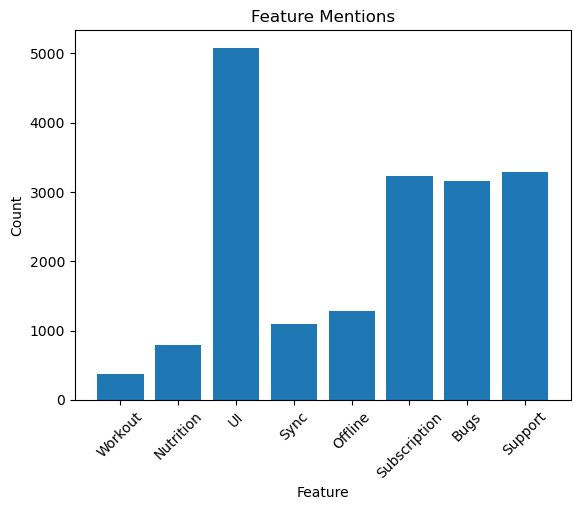

In [34]:

plt.bar(feature_counts.keys(), feature_counts.values())
plt.title('Feature Mentions')
plt.xlabel('Feature')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


In [31]:
#feature_counts = []

#for feature, keywords in features.items():
    #mask = df['clean_text'].apply(lambda x: any(k in x for k in keywords))
    #count = mask.sum()
    #feature_counts.append([feature, count, count / len(df) * 100])

#feature_df = pd.DataFrame(feature_counts, columns=['Feature', 'Mentions', 'Percent'])


In [32]:
#feature_df

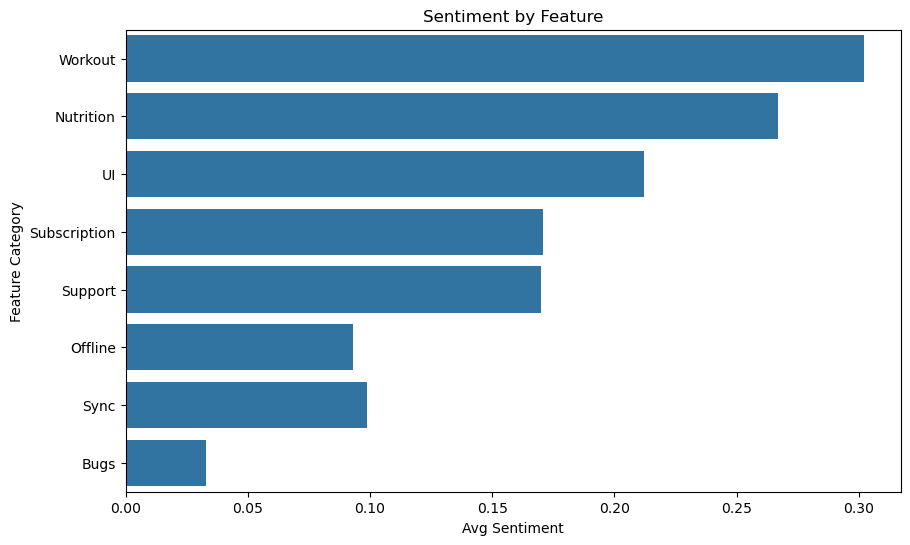

In [35]:
plt.figure(figsize=(10,6))
sns.barplot(x='Avg Sentiment', y='Feature Category', data=sentiment_by_feature)
plt.title('Sentiment by Feature')
plt.show()

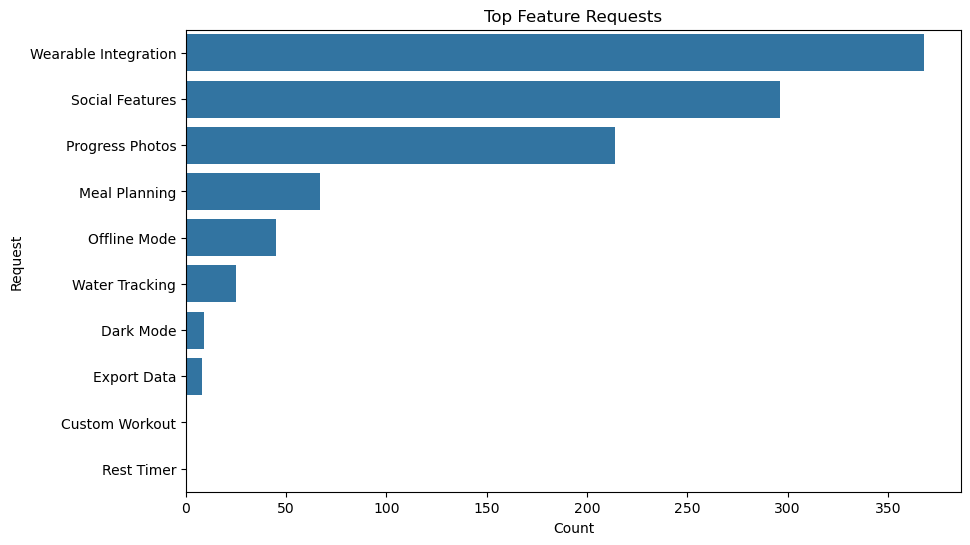

In [90]:
plt.figure(figsize=(10,6))
sns.barplot(x='Count', y='Request', data=request_df.head(10))
plt.title('Top Feature Requests')
plt.show()

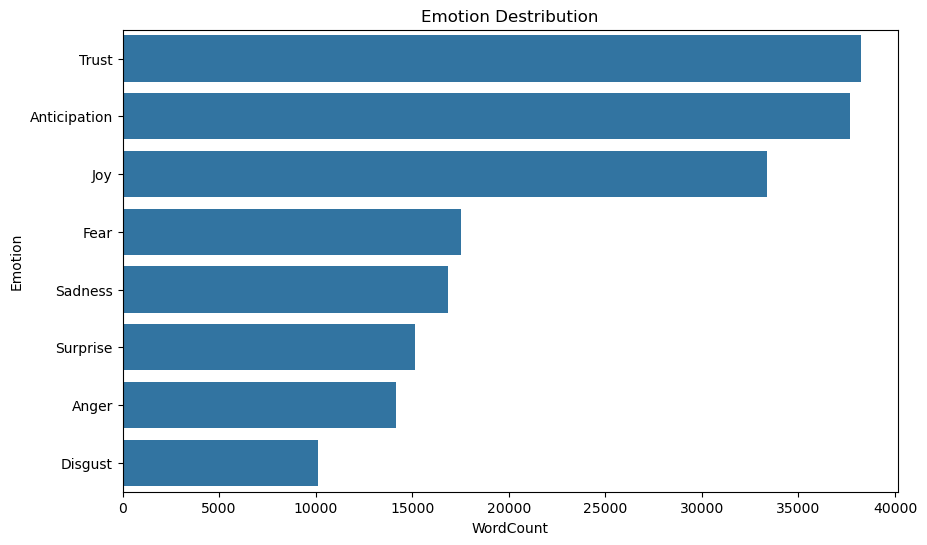

In [41]:
plt.figure(figsize=(10,6))
sns.barplot(x='WordCount', y='Emotion', data=emotion_table)
plt.title('Emotion Destribution')
plt.show()

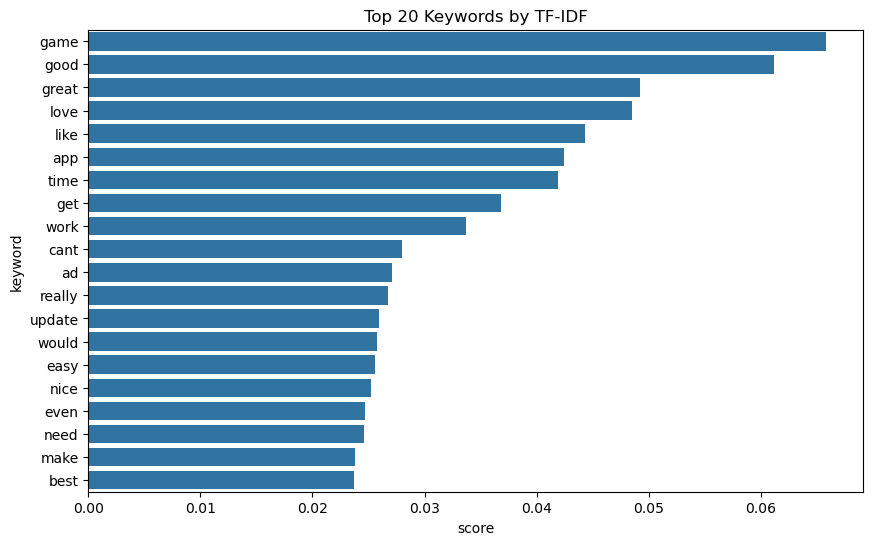

In [120]:
plt.figure(figsize=(10,6))
word_freq = top_keywords.head(20)
sns.barplot(x='score', y='keyword', data=word_freq)
plt.title('Top 20 Keywords by TF-IDF')
plt.show()